In [196]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from my_functions import df_to_table, move_column

pd.set_option('display.max_columns', None)

# Combine datasets

In [197]:
gaming_data = pd.read_csv('../data/gaming_GAD_CLEAN.csv')
nhis_data = pd.read_csv('../data/nhis_GAD_CLEAN.csv')

In [198]:
# Check what columns are different between the two dataframes

set(gaming_data.columns) ^ set(nhis_data.columns)

{'Degree',
 'Gender',
 'game',
 'hours',
 'participant_id_OLD',
 'platform',
 'playstyle',
 'reason',
 'region_id'}

In [199]:
df = pd.concat([gaming_data, nhis_data], ignore_index=True, sort=False)
df.head()

# Reference: https://pandas.pydata.org/docs/user_guide/merging.html

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
0,0,1,2015,0,0,0,0,1,0,0,1,1,1,25,8,1,USA,Skyrim,Bachelor (or equivalent),"Console (PS, Xbox, ...)",15.0,having fun,Singleplayer,Male,NaN,NaN
1,1,2,2015,1,2,2,2,0,1,0,8,2,1,41,8,1,USA,Other,Bachelor (or equivalent),PC,8.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN
2,2,3,2015,0,2,2,0,0,3,1,8,2,2,32,8,1,DEU,Other,Bachelor (or equivalent),PC,0.0,having fun,Singleplayer,Female,NaN,NaN
3,3,4,2015,0,0,0,0,0,0,0,0,1,1,28,8,1,USA,Other,Bachelor (or equivalent),PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,NaN,NaN
4,4,5,2015,2,1,2,2,2,3,2,14,3,1,19,12,1,KOR,Other,High school diploma (or equivalent),"Console (PS, Xbox, ...)",20.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


In [200]:
# This remains from an unknown issue before where both datasets had a participant with this id
filtered_data = df.loc[df['participant_id'] == 43]
filtered_data

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
42,42,43,2015,0,0,0,0,0,0,0,0,1,1,27,8,1,USA,Other,Bachelor (or equivalent),PC,12.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


In [201]:
# Confirming that the data fix was successful

filtered_data = df.loc[df['GAD_total'] > 21]
filtered_data

# GAD_total needs to be recalculated after data correction

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD


In [202]:
# Confirm that no number is >21
df['GAD_total'].unique()

array([ 1,  8,  0, 14, 12, 10, 19,  3,  2,  4, 15,  5,  6,  7, 13, 11,  9,
       18, 16, 21, 17, 20])

# Build Relational Tables

## Create unique dataframes

In [203]:
# ================
# Fact tables
# ================

participant_df = df[['participant_id', 'survey_id', 'sex_id', 'education_id', 'residence', 'age', 'region_id']].drop_duplicates()

GAD_response_df = df[['participant_id', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'GAD_total', 'GAD_cat']]

gaming_response_df = df[['participant_id', 'survey_id', 'game', 'platform', 'hours', 'reason', 'playstyle']].drop_duplicates()

# ================
# Lookup tables
# ================

survey_df = pd.DataFrame({
    'survey_id': [1, 2],
    'survey_name': ['Gamers', 'NHIS'],
    'year': [2015, 2019],
    'population':['global', 'America']
})


GAD_categories = {
    1:'None/Minimal (0-4)', 
    2:'Mild (5-9)', 
    3:'Moderate (10-14)', 
    4:'Severe (>15)', 
    8:'Not Ascertained'
}

GAD_cat_df = (
    pd.Series(GAD_categories, name='cat_name')
        .rename_axis('GAD_cat')
        .reset_index()
)

sex_lookup = {
    1: 'Male', 
    2:'Female',
    3: 'Other', 
    7:'Refused', 
    8:'Not Ascertained',
    9:"Don't Know"
}
sex_df = (
    pd.Series(sex_lookup, name='sex_name')
        .rename_axis('sex_id')
        .reset_index()
)


degree_lookup = {
    0:'Never attended/kindergarten only', 
    1: 'Grade 1-11',
    2: '12th grade, no diploma',
    3: 'GED or equivalent',
    4: 'High School Graduate',
    5: 'Some college, no degree',
    6: 'Associate degree: occupational, technical, or vocational program',
    7: 'Associate degree: academic program',
    8: "Bachelor's degree (Example: BA, AB, BS, BBA)",
    9: "Master's degree or equivalent (Example: MA, MS, MEng, MEd, MBA)",
    10: "Professional School degree (Example: MD, DDS, DVM, JD)",
    11: "Doctoral degree (Example: PhD, EdD)",
    12: "High school diploma (or equivalent)",
    13: "Ph.D., Psy. D., MD (or equivalent)",
    97: "Refused",
    98: "Not Ascertained",
    99:"Don't Know"
}
education_df = (
    pd.Series(degree_lookup, name='level')
        .rename_axis('education_id')
        .reset_index()
)


region_lookup = {
    1: 'Northeast',
    2: 'Midwest',
    3: 'South', 
    4: 'West'
}
region_df = (
    pd.Series(region_lookup, name='name')
        .rename_axis('region_id')
        .reset_index()
)

# I conferred with ChatGPT to decide how to set up the lookup tables
# it recommended using dictionaries to set them up to make it easier to 
# read and maintain. I did this for the longer descriptions

## Add custom id columns to GAD_response_df and gaming_response_df
This will be a unique identifier and primary key

Reference: https://www.geeksforgeeks.org/python/create-a-pandas-column-using-for-loop/

In [204]:
def add_custom_id_column(dataframe, new_col_name, first_id_no):
    if new_col_name in dataframe:
        return
    else:
        new_col_data = []
        id_no = first_id_no

        for participant in dataframe['participant_id']:
            new_col_data.append(id_no)
            id_no += 1

        dataframe[new_col_name] = new_col_data

        col_to_move = dataframe.pop(new_col_name)
        dataframe.insert(0, new_col_name, col_to_move)

add_custom_id_column(GAD_response_df, 'GAD_response_id', 1000)

GAD_response_df.head()

,GAD_response_id,participant_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1000,1,0,0,0,0,1,0,0,1,1
1,1001,2,1,2,2,2,0,1,0,8,2
2,1002,3,0,2,2,0,0,3,1,8,2
3,1003,4,0,0,0,0,0,0,0,0,1
4,1004,5,2,1,2,2,2,3,2,14,3


In [205]:
add_custom_id_column(gaming_response_df, 'gaming_response_id', 2000)

gaming_response_df.head()

,gaming_response_id,participant_id,survey_id,game,platform,hours,reason,playstyle
0,2000,1,1,Skyrim,"Console (PS, Xbox, ...)",15.0,having fun,Singleplayer
1,2001,2,1,Other,PC,8.0,having fun,Multiplayer - online - with strangers
2,2002,3,1,Other,PC,0.0,having fun,Singleplayer
3,2003,4,1,Other,PC,20.0,improving,Multiplayer - online - with online acquaintanc...
4,2004,5,1,Other,"Console (PS, Xbox, ...)",20.0,having fun,Multiplayer - online - with strangers


## Create database tables

In [206]:
conn = sqlite3.connect('../data/mentalhealth.db')

df_to_table(participant_df, 'participant', conn)
df_to_table(GAD_response_df, 'GAD_response', conn)
df_to_table(gaming_response_df, 'gaming_response', conn)
df_to_table(survey_df, 'survey', conn)
df_to_table(GAD_cat_df, 'GAD_category', conn)
df_to_table(sex_df, 'sex', conn)
df_to_table(education_df, 'education', conn)
df_to_table(region_df, 'region', conn)

# Exploratory Data Analysis

## QUERIES

### Create a temporary view

In [207]:
# conn.execute is better to use to modify data where
# pd.read_sql is best to pull query results

# I consulted with Chat GPT here for a way to reduce the 
# amount of repetitive SQL code I originally had.

conn.execute("""
    CREATE TEMP VIEW gad_eda_data AS
    SELECT
        p.participant_id,
        p.survey_id,
        p.sex_id,
        p.education_id,
        p.residence,
        p.age,
        p.region_id,
        r.GAD1,
        r.GAD2,
        r.GAD3,
        r.GAD4,
        r.GAD5,
        r.GAD6,
        r.GAD7,
        r.GAD_total,
        r.GAD_cat
    FROM participant p
    JOIN GAD_response r on r.participant_id = p.participant_id
""")

In [208]:
all_data_scores_q = """
SELECT * FROM gad_eda_data
"""

all_data_scores_r = pd.read_sql(all_data_scores_q, conn)
all_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,3,1,2,8,DEU,32,NaN,0,1,1,1,1,1,1,6,2
3,3,1,2,8,DEU,32,NaN,0,2,2,0,0,3,1,8,2
4,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57451,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
57452,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
57453,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
57454,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


### Participant data and scores (USA) (usa_data_scores_r)

In [209]:
usa_data_scores_q = """
SELECT * FROM gad_eda_data
WHERE residence = "USA"
"""

usa_data_scores_r = pd.read_sql(usa_data_scores_q, conn)
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44407,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
44408,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
44409,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
44410,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


### NHIS data and scores (nhis_data_scores_r)

In [210]:
nhis_data_scores_q = """
SELECT * FROM gad_eda_data
WHERE survey_id = 2
"""

nhis_data_scores_r = pd.read_sql(nhis_data_scores_q, conn)
nhis_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,48109,2,1,7,USA,97,3.0,0,0,0,0,0,0,0,0,1
1,27044,2,2,6,USA,28,3.0,0,0,1,0,0,1,1,3,1
2,58855,2,1,5,USA,72,3.0,0,0,0,0,0,0,0,0,1
3,31993,2,1,7,USA,60,3.0,0,0,0,0,0,0,0,0,1
4,7122,2,1,5,USA,60,3.0,2,1,1,1,0,0,1,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37627,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
37628,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
37629,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
37630,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


### Gamer data and scores (USA) (usa_gamer_data_scores_r)

In [211]:
usa_gamer_data_scores_q = """
SELECT * FROM gad_eda_data
WHERE survey_id = 1
    AND residence = "USA"
"""

usa_gamer_data_scores_r = pd.read_sql(usa_gamer_data_scores_q, conn)
usa_gamer_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,None,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,None,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,None,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,None,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,None,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775,14240,1,1,12,USA,24,None,3,3,1,3,3,3,0,16,4
6776,14245,1,1,12,USA,21,None,0,0,0,0,0,0,0,0,1
6777,14245,1,1,12,USA,21,None,0,1,1,1,0,2,1,6,2
6778,14247,1,2,12,USA,20,None,0,0,0,0,0,0,0,0,1


In [212]:
all_gamer_data_scores_q = """
SELECT * FROM gad_eda_data
WHERE survey_id = 1
"""

all_gamer_data_scores_r = pd.read_sql(all_gamer_data_scores_q, conn)
all_gamer_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,None,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,None,1,2,2,2,0,1,0,8,2
2,3,1,2,8,DEU,32,None,0,1,1,1,1,1,1,6,2
3,3,1,2,8,DEU,32,None,0,2,2,0,0,3,1,8,2
4,4,1,1,8,USA,28,None,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19819,14247,1,2,12,USA,20,None,3,3,3,3,2,3,3,20,4
19820,14248,1,1,12,NOR,19,None,0,0,0,0,0,0,0,0,1
19821,14248,1,1,12,NOR,19,None,0,0,0,0,0,0,0,0,1
19822,14249,1,2,12,CAN,18,None,3,2,1,3,0,1,3,13,3


### Scores by sex (sex_data_scores_r)

In [213]:
# Look into using this with the gad_eda_data

sex_data_scores_q = """
SELECT
    g.sex_id,
    s.sex_name,
    AVG(g.GAD1),
    AVG(g.GAD2),
    AVG(g.GAD3),
    AVG(g.GAD4),
    AVG(g.GAD5),
    AVG(g.GAD6),
    AVG(g.GAD7),
    AVG(g.GAD_total),
    AVG(g.GAD_cat),
    count(g.sex_id) as total_participants
FROM gad_eda_data g
JOIN sex s on s.sex_id = g.sex_id
GROUP BY g.sex_id
"""

sex_data_scores_r = pd.read_sql(sex_data_scores_q, conn)
sex_data_scores_r

,sex_id,sex_name,AVG(g.GAD1),AVG(g.GAD2),AVG(g.GAD3),AVG(g.GAD4),AVG(g.GAD5),AVG(g.GAD6),AVG(g.GAD7),AVG(g.GAD_total),AVG(g.GAD_cat),total_participants
0,1,Male,0.531893,0.404154,0.576377,0.449193,0.310306,0.570220,0.336763,3.178906,1.391952,36058
1,2,Female,0.511556,0.428062,0.557686,0.449534,0.259247,0.501102,0.307346,3.014533,1.380854,21331
2,3,Other,1.343750,1.031250,1.234375,1.187500,0.718750,0.984375,0.890625,7.390625,2.140625,64
3,7,Refused,1.666667,1.666667,0.666667,0.666667,0.333333,1.666667,1.000000,7.666667,2.333333,3


### NOT CURRENTLY USED SQLite queries

#### NOT CURRENTLY USED Gamer data and scores (World) (all_gamer_data_scores_r)

#### NOT CURRENTLY USED Participant data and scores (all_data_scores_r) 

#### NOT CURRENTLY USED Scores by age (usa_age_data_scores_r)
Note that this *may* skew results somewhat as the majority of participants of the gamer survey were in their early 20s.

In [214]:
usa_age_data_scores_q = """
SELECT
    age,
    AVG(GAD1) AS GAD1,
    AVG(GAD2) AS GAD2,
    AVG(GAD3) AS GAD3,
    AVG(GAD4) AS GAD4,
    AVG(GAD5) AS GAD5,
    AVG(GAD6) AS GAD6,
    AVG(GAD7) AS GAD7,
    AVG(GAD_total) AS GAD_total,
    AVG(GAD_cat) AS GAD_cat,
    count(age) as total_participants
FROM gad_eda_data
GROUP BY age
"""

usa_age_data_scores_r = pd.read_sql(usa_age_data_scores_q, conn)
usa_age_data_scores_r

,age,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,total_participants
0,18,0.676918,0.535848,0.773824,0.564098,0.391024,0.776506,0.480780,4.198999,1.543179,5593
1,19,0.656928,0.508533,0.737923,0.524732,0.373445,0.699450,0.440845,3.941857,1.495806,3457
2,20,0.682927,0.547176,0.762516,0.564185,0.386714,0.690308,0.443196,4.077022,1.525995,3116
3,21,0.685804,0.534801,0.748329,0.578451,0.379866,0.683052,0.457334,4.067637,1.521825,2543
4,22,0.704390,0.566341,0.778049,0.595122,0.355610,0.673659,0.418537,4.091707,1.516098,2050
...,...,...,...,...,...,...,...,...,...,...,...
65,83,0.425197,0.354331,0.460630,0.291339,0.185039,0.393701,0.287402,2.397638,1.299213,254
66,84,0.306977,0.320930,0.390698,0.255814,0.162791,0.293023,0.195349,1.925581,1.195349,215
67,85,0.406026,0.315638,0.398852,0.296270,0.190818,0.322812,0.250359,2.180775,1.253945,1394
68,97,0.343284,0.283582,0.343284,0.238806,0.164179,0.343284,0.149254,1.865672,1.283582,67


#### NOT CURRENTLY USED Scores by education (all_gamer_ed_data_scores_r)

In [215]:
# Look into using this with the gad_eda_data

all_gamer_ed_data_scores_q = """
SELECT
    education_id,
    AVG(GAD1),
    AVG(GAD2),
    AVG(GAD3),
    AVG(GAD4),
    AVG(GAD5),
    AVG(GAD6),
    AVG(GAD7),
    AVG(GAD_total),
    AVG(GAD_cat),
    count(education_id) as total_participants
FROM gad_eda_data
GROUP BY education_id
"""

all_gamer_ed_data_scores_r = pd.read_sql(all_gamer_ed_data_scores_q, conn)
all_gamer_ed_data_scores_r

,education_id,AVG(GAD1),AVG(GAD2),AVG(GAD3),AVG(GAD4),AVG(GAD5),AVG(GAD6),AVG(GAD7),AVG(GAD_total),AVG(GAD_cat),total_participants
0,0,0.388350,0.242718,0.281553,0.368932,0.281553,0.349515,0.252427,2.165049,1.233010,103
1,1,0.546763,0.485971,0.606835,0.482374,0.367266,0.530576,0.381295,3.401079,1.446403,2780
2,2,0.426987,0.364140,0.486137,0.367837,0.301294,0.489834,0.279113,2.715342,1.345656,541
3,3,0.599558,0.545354,0.678097,0.565265,0.418142,0.609513,0.361726,3.777655,1.508850,904
4,4,0.420113,0.356756,0.471605,0.365165,0.246285,0.444073,0.265983,2.569980,1.317705,8681
5,5,0.469915,0.361184,0.491007,0.405003,0.259810,0.486756,0.268640,2.742315,1.340582,6116
6,6,0.453306,0.386503,0.488071,0.419905,0.271984,0.482618,0.263122,2.765508,1.342877,1467
7,7,0.435263,0.350015,0.478324,0.377946,0.237707,0.472796,0.258947,2.610998,1.315682,3437
8,8,0.500737,0.366508,0.516615,0.428712,0.253069,0.496071,0.282207,2.843919,1.342855,12218
9,9,0.441347,0.302809,0.440703,0.362642,0.201158,0.430410,0.226893,2.405962,1.273429,4663


## Visualizations

- box & whisker plot of scores (total and by survey)

### Heat map: Is there an observable and unexptected correlation in the data?

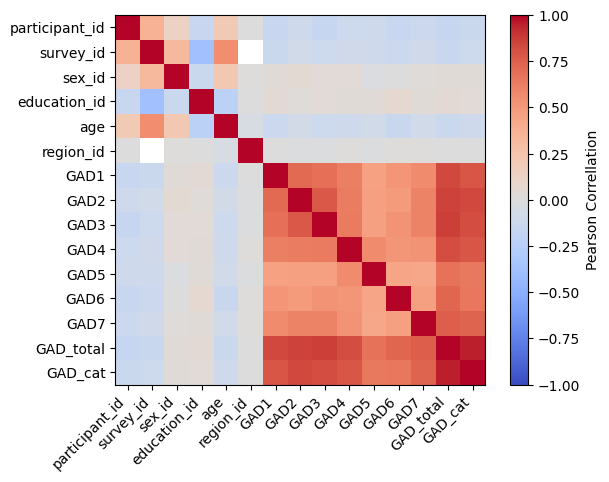

In [216]:
numeric_usa_df = usa_data_scores_r.select_dtypes(include=[np.number])
corr = numeric_usa_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Pearson Correllation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

There do not appear to be any strong, unexpected correlations revealed by this heat map.

### Pie chart: What is the division of participants' identified sex?

In [217]:
category = 'sex_name'
values = 'total_participants'

sex_totals = sex_data_scores_r.groupby(category)[values].sum()
sex_totals

sex_name
Female     21331
Male       36058
Other         64
Refused        3
Name: total_participants, dtype: int64

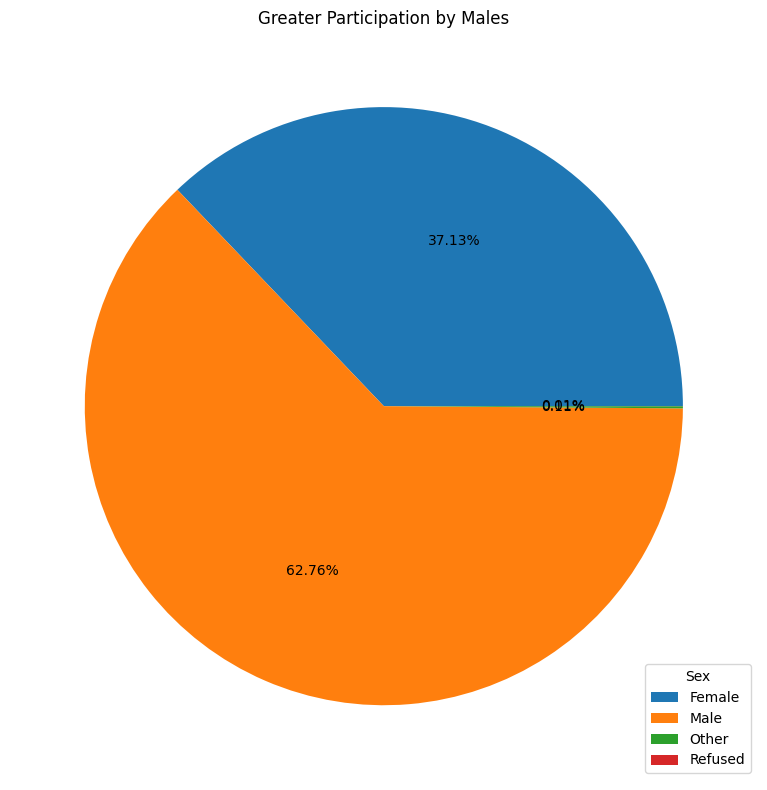

In [218]:
plt.figure(figsize=(8,8))
plt.pie(
    sex_totals,
    labels=None,
    autopct='%1.2f%%'
)

plt.title('Greater Participation by Males')

plt.legend(
    labels=sex_totals.index,
    loc='lower right',
    title='Sex'
)

plt.tight_layout()
plt.show()

### Bar chart: What is the average GAD score for each survey? (USA)

In [219]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44407,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
44408,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
44409,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
44410,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


In [220]:
avg_score = usa_data_scores_r.groupby('survey_id')['GAD_total'].mean()
avg_score

survey_id
1    4.220649
2    2.582802
Name: GAD_total, dtype: float64

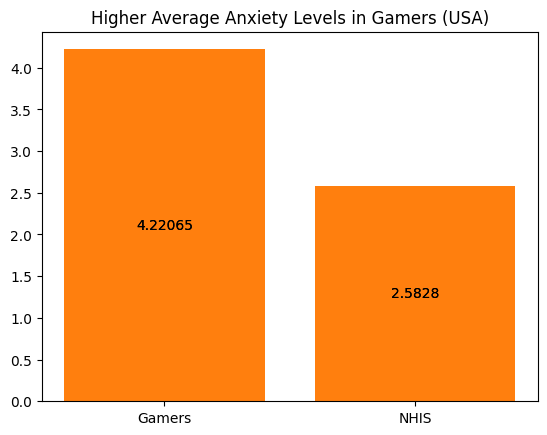

In [221]:
surveys = ('Gamers', 'NHIS')

fig, ax = plt.subplots()
bottom = np.zeros(2)

for survey in avg_score.items():
    p = ax.bar(surveys, avg_score, label=survey, bottom=bottom)
    ax.bar_label(p, label_type='center')

ax.set_title('Higher Average Anxiety Levels in Gamers (USA)')

plt.show()

# Reference: 
#   x-tick labels: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

### Count plots of avg scores

In [222]:
def visualize_count_plot(dataframe, x_label_name, y_label_name, plot_name):
    plt.bar(dataframe.index, dataframe.values)

    plt.xlabel(x_label_name)
    plt.ylabel(y_label_name)
    plt.title(plot_name)

    plt.show()

#### How do the GAD score totals compare across all participants?

In [223]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44407,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
44408,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
44409,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
44410,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


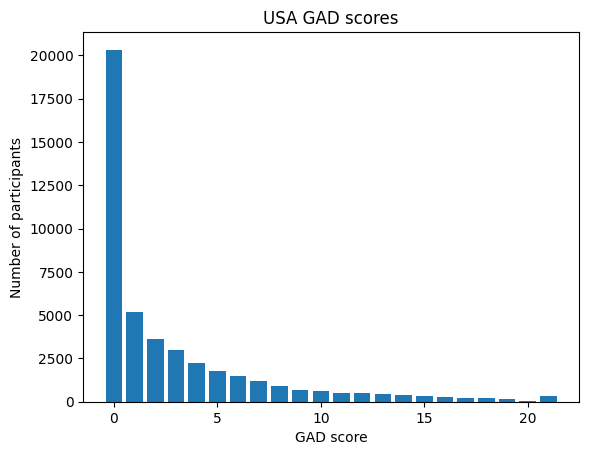

In [224]:
usa_score_count = usa_data_scores_r['GAD_total'].value_counts()

visualize_count_plot(usa_score_count, 'GAD score', 'Number of participants', 'USA GAD scores')

In [225]:
# investigating  why any number is above total possible GAD score of 21
# usa_data_scores_r['GAD_total'].unique()

In [226]:
# filtered_scores = usa_data_scores_r.loc[usa_data_scores_r['GAD_total'] > 21]
# filtered_scores

# The highest number that SHOULD be possible in the GAD1-7 columns is 3.

#### How do the GAD score totals compare across USA gamer participants?

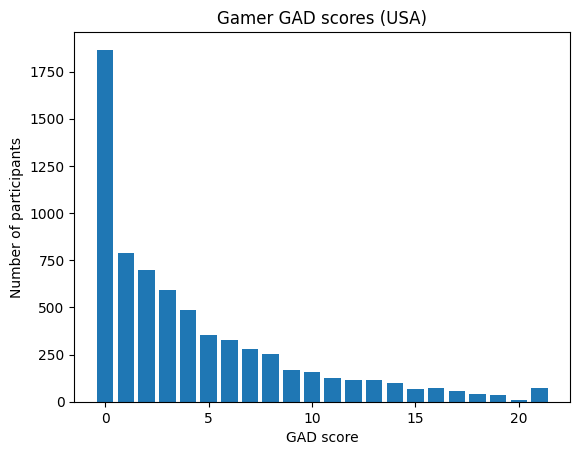

In [227]:
usa_gamer_data_scores = usa_gamer_data_scores_r['GAD_total'].value_counts()

visualize_count_plot(usa_gamer_data_scores, 'GAD score', 'Number of participants', 'Gamer GAD scores (USA)')

#### How do the GAD score totals compare across NHIS participants?

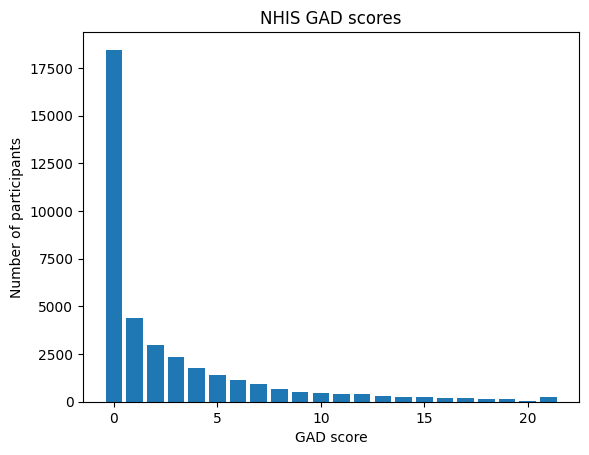

In [228]:
nhis_data_scores = nhis_data_scores_r['GAD_total'].value_counts()

visualize_count_plot(nhis_data_scores, 'GAD score', 'Number of participants', 'NHIS GAD scores')

#### How do the GAD score totals compare across age?

In [229]:
# usa_age_data_scores_r['age'].value_counts()

# Ages range from 18-99

In [230]:
#  The original exploration here can be found in preliminary_analysis/notebooks/eda.ipynb, including resources

# Commented out because this does not accomplish what I am wanting to visualize. This groups the average scores of average scores and it feels like that muddies the comparison further than a count plot would.

# bins = [18, 29, 39, 49, 59, 69, 79, 89, 99]
# labels = ['18-28', '29-38','39-48', '49-58', '59-68', '69-78', '79-88', '88+']

# usa_age_data_scores_r['age_binned'] = pd.cut(usa_age_data_scores_r['age'], bins=bins, labels=labels)

# usa_age_data_scores_r.head()


# usa_age_data_scores_r = usa_age_data_scores_r['GAD_total'].value_counts()

# plt.bar(usa_age_data_scores_r.index, usa_age_data_scores_r.values)

# plt.show()

##### All USA user GAD scores by age
There is a large gap in the higher ages; data may need to be trimmed of users above ~age 85. Further investigation is needed.

Upon further investigation, I elected to keep the data and make a subset of data concentrated on 18-

In [231]:
# Custom dataframes for charts

usa_data = df.loc[df['residence'] == 'USA']
nhis_data = df.loc[(df['survey_id'] == 2)]
gaming_usa_data = df.loc[(df['survey_id'] == 1) & (df['residence'] == 'USA')]

age_counts = df.groupby('age')['GAD_total'].mean()
usa_age_counts = usa_data.groupby('age')['GAD_total'].mean()
gaming_age_counts = gaming_usa_data.groupby('age')['GAD_total'].mean()
nhis_age_counts = nhis_data.groupby('age')['GAD_total'].mean()


education_counts = df.groupby('education_id')['GAD_total'].mean()
usa_education_counts = usa_data.groupby('education_id')['GAD_total'].mean()

sex_counts = df.groupby('sex_id')['GAD_total'].mean()
usa_sex_counts = usa_data.groupby('sex_id')['GAD_total'].mean()

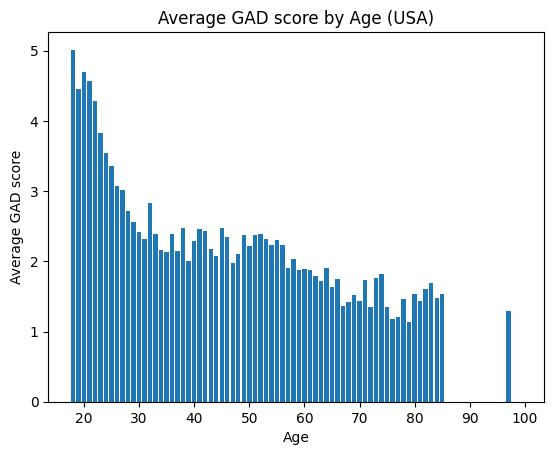

In [232]:
visualize_count_plot(usa_age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (USA)')

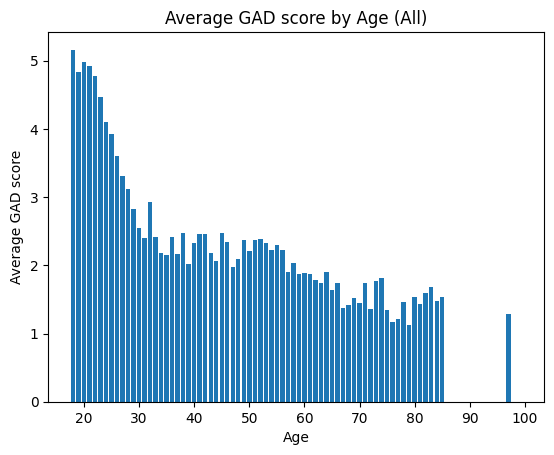

In [233]:
visualize_count_plot(age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (All)')

##### Gaming USA participant GAD scores by age

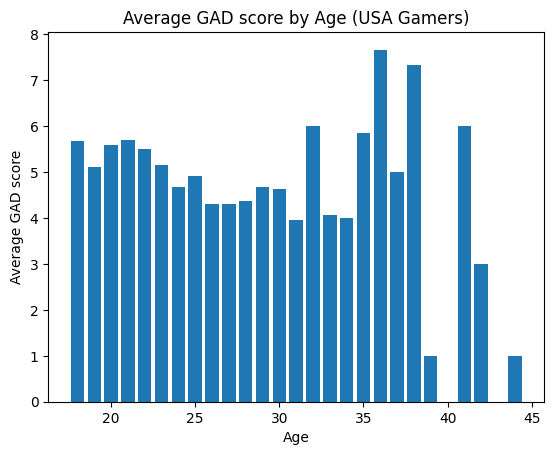

In [234]:
visualize_count_plot(gaming_age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (USA Gamers)')

##### NHIS participant GAD scores by age

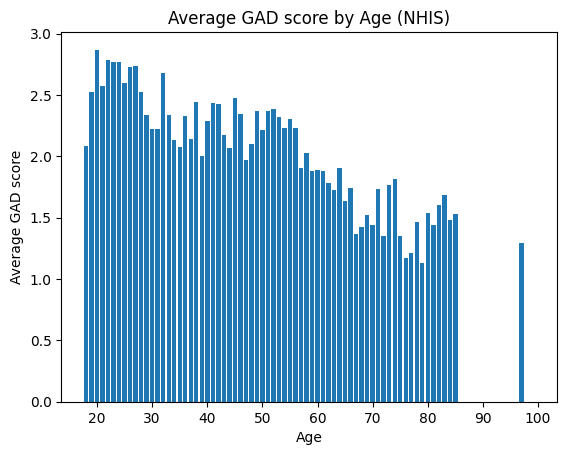

In [235]:
visualize_count_plot(nhis_age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (NHIS)')

#### How do the GAD score totals compare across reported education level?

For now, this data is displaying awkwardly because of the categories' numerical labels. In the final analysis, if I choose to investigate this further, this will be much more readable and labeled appropriately.

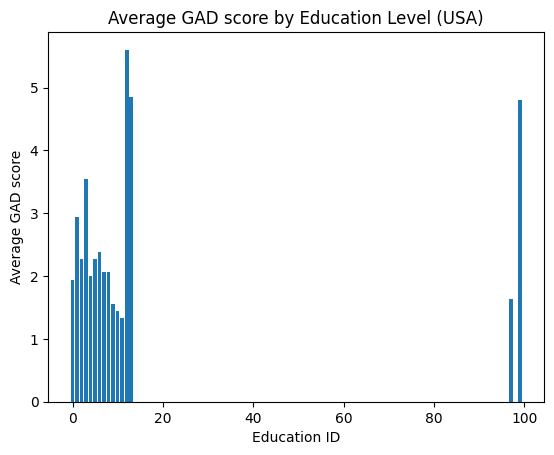

In [236]:
ax = visualize_count_plot(usa_education_counts, 'Education ID', 'Average GAD score', 'Average GAD score by Education Level (USA)')



In [237]:
def visualize_and_label_count_plot(dataframe, x_label_name, y_label_name, plot_name, label_lookup):
    positions = range(len(dataframe))

    plt.bar(positions, dataframe.values)

    plt.xticks(
        positions,
        [label_lookup[i] for i in dataframe.index],
        rotation=45,
        ha='right'
    )

    plt.xlabel(x_label_name)
    plt.ylabel(y_label_name)
    plt.title(plot_name)

    plt.show()

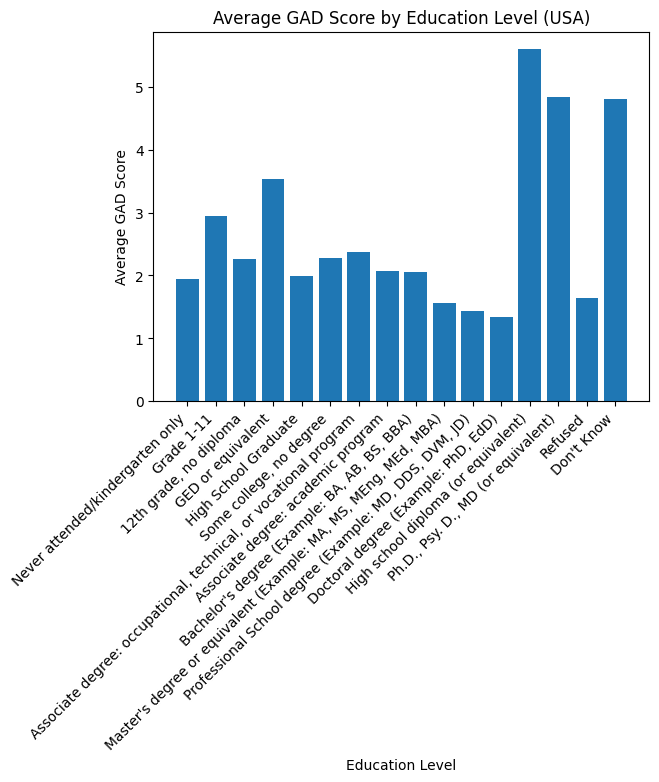

In [238]:
# plt.bar(usa_education_counts.index, usa_education_counts.values)

# plt.xlabel('Education Level')
# plt.ylabel('Average GAD Score')
# plt.title('Avg GAd by Ed Level USA')

# plt.xticks(
#     list(degree_lookup.keys()),
#     list(degree_lookup.values()), 
#     rotation=45,
#     ha='right'
#     )
# I used ChatGPT to learn that the keys/values needed 
# to be converted to a list to relabel the xaxis. Then
# to learn how to eliminate the big gap caused by the 
# range of education_id numbers below

# positions = range(len(usa_education_counts))

# plt.bar(positions, usa_education_counts.values)

# plt.xticks(
#     positions,
#     [degree_lookup[i] for i in usa_education_counts.index],
#     rotation=45,
#     ha='right'
# )

# plt.ylabel('Average GAD Score')
# plt.title('Avg GAD by Ed Level USA')

# plt.show()

visualize_and_label_count_plot(usa_education_counts, 'Education Level', 'Average GAD Score', 'Average GAD Score by Education Level (USA)', degree_lookup)


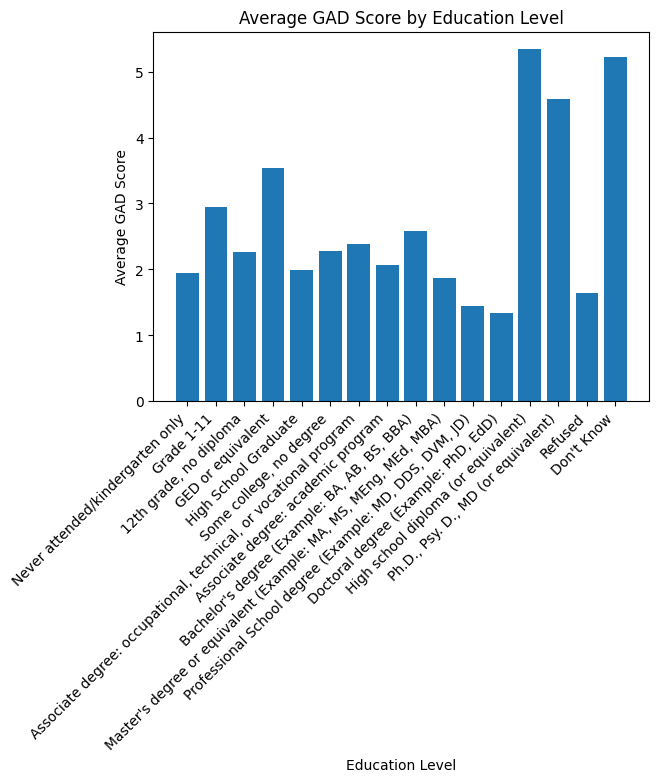

In [239]:
visualize_and_label_count_plot(education_counts, 'Education Level', 'Average GAD Score', 'Average GAD Score by Education Level', degree_lookup)

#### How do the GAD score totals compare across reported sex?
For now, this data is displaying awkwardly because of the categories' numerical labels. In the final analysis, if I choose to investigate this further, this will be much more readable and labeled appropriately.

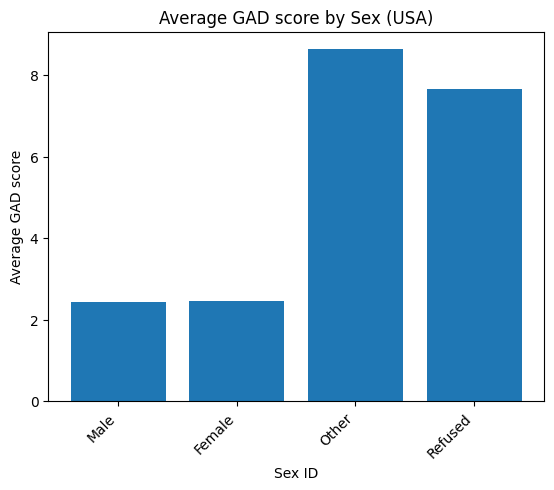

In [240]:
# visualize_count_plot(usa_sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (USA)')
visualize_and_label_count_plot(usa_sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (USA)', sex_lookup)

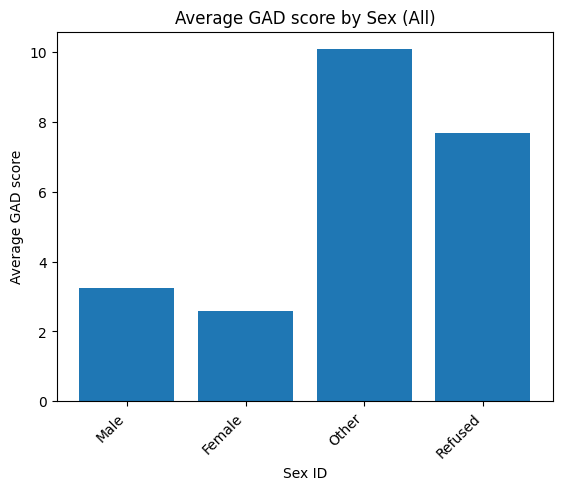

In [251]:
# visualize_count_plot(sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (All)')
visualize_and_label_count_plot(sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (All)', sex_lookup)

#### Investigate division of ages
The gaming data is primarily younger participants. It would be a more fair analysis to compare similar age groups.

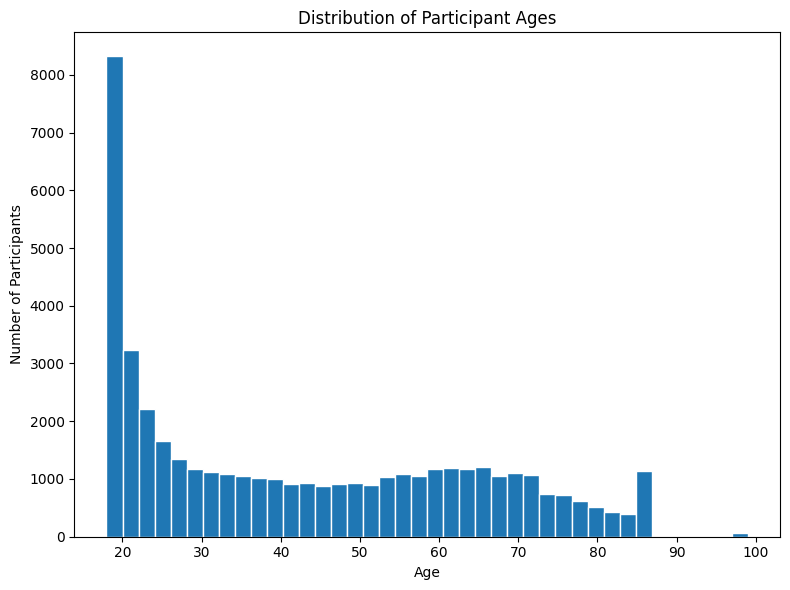

In [243]:
plt.figure(figsize=(8,6))

# Age ranges from 18-99
# Largest concentration of participants from 18-22
plt.hist(
    df['age'],
    bins=40,
    edgecolor = "white"
)

plt.xlabel('Age')
plt.ylabel('Number of Participants')
plt.title('Distribution of Participant Ages')

plt.tight_layout()
plt.show()

#### Compare NHIS and Gaming scores (ages 18-22 only)

In [244]:
gaming_usa_18_22 = gaming_usa_data[gaming_usa_data['age'].between(18,22)]
nhis_18_22 = nhis_data[nhis_data['age'].between(18,22)]

gaming_usa_18_22_scores = gaming_usa_18_22.groupby('age')['GAD_total'].mean()
nhis_18_22_scores = nhis_18_22.groupby('age')['GAD_total'].mean()


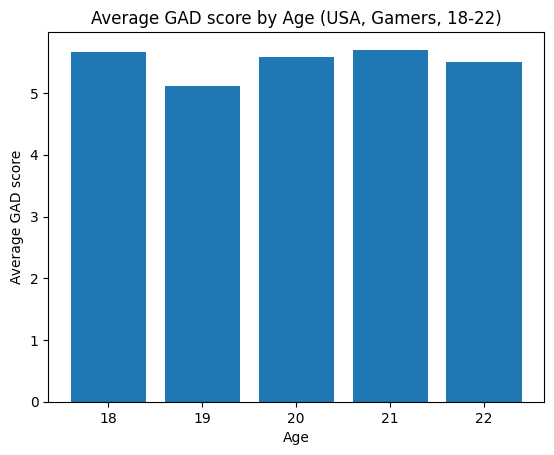

In [252]:
visualize_count_plot(gaming_usa_18_22_scores, 'Age', 'Average GAD score', 'Average GAD score by Age (USA, Gamers, 18-22)')

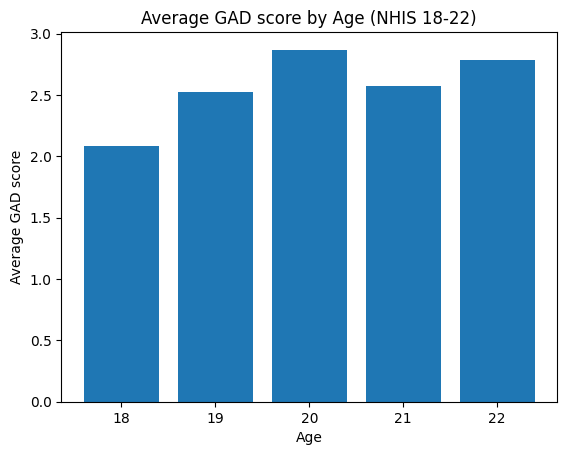

In [246]:
visualize_count_plot(nhis_18_22_scores, 'Age', 'Average GAD score', 'Average GAD score by Age (NHIS 18-22)')

### Boxplots

#### GAD scores

In [247]:
df.head()

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
0,0,1,2015,0,0,0,0,1,0,0,1,1,1,25,8,1,USA,Skyrim,Bachelor (or equivalent),"Console (PS, Xbox, ...)",15.0,having fun,Singleplayer,Male,NaN,NaN
1,1,2,2015,1,2,2,2,0,1,0,8,2,1,41,8,1,USA,Other,Bachelor (or equivalent),PC,8.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN
2,2,3,2015,0,2,2,0,0,3,1,8,2,2,32,8,1,DEU,Other,Bachelor (or equivalent),PC,0.0,having fun,Singleplayer,Female,NaN,NaN
3,3,4,2015,0,0,0,0,0,0,0,0,1,1,28,8,1,USA,Other,Bachelor (or equivalent),PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,NaN,NaN
4,4,5,2015,2,1,2,2,2,3,2,14,3,1,19,12,1,KOR,Other,High school diploma (or equivalent),"Console (PS, Xbox, ...)",20.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


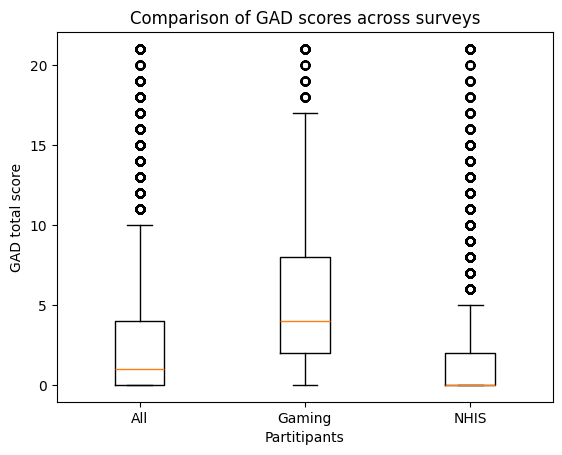

In [248]:
plt.boxplot(
    [df['GAD_total'],
    df[df['survey_id'] == 1]['GAD_total'],
    df[df['survey_id'] == 2]['GAD_total']
    ],
    tick_labels=['All', 'Gaming', 'NHIS']
)

plt.xlabel('Partitipants')
plt.ylabel('GAD total score')
plt.title('Comparison of GAD scores across surveys')

plt.show()

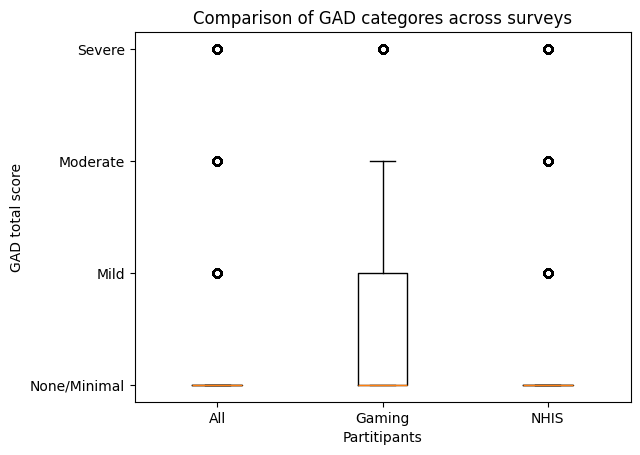

In [249]:
plt.boxplot(
    [df['GAD_cat'],
    df[df['survey_id'] == 1]['GAD_cat'],
    df[df['survey_id'] == 2]['GAD_cat']
    ],
    tick_labels=['All', 'Gaming', 'NHIS']
)

plt.yticks(ticks=[1, 2, 3, 4],
            labels=['None/Minimal', 'Mild', 'Moderate', 'Severe'])


plt.xlabel('Partitipants')
plt.ylabel('GAD total score')
plt.title('Comparison of GAD categores across surveys')

plt.show()

### Ages

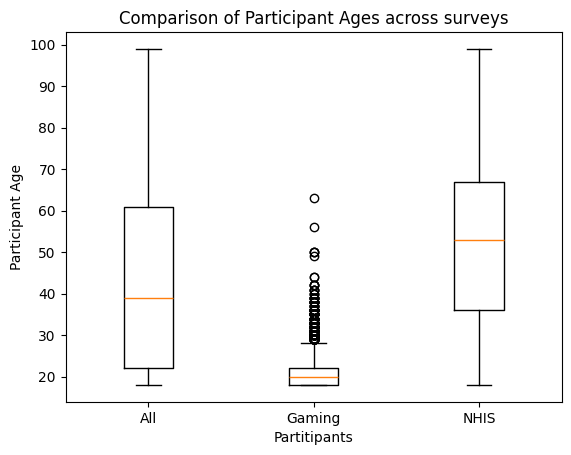

In [250]:
plt.boxplot(
    [df['age'],
    df[df['survey_id'] == 1]['age'],
    df[df['survey_id'] == 2]['age']
    ],
    tick_labels=['All', 'Gaming', 'NHIS']
)

# plt.yticks(ticks=[1, 2, 3, 4],
#             labels=['None/Minimal', 'Mild', 'Moderate', 'Severe'])


plt.xlabel('Partitipants')
plt.ylabel('Participant Age')
plt.title('Comparison of Participant Ages across surveys')

plt.show()

### Gaming Analysis
Please see preliminary_analysis/notebooks/eda for initial EDA of gaming data

## EDA observations:
- Overall, more males participated in the surveys
- Gamers exhibited a higher average GAD score, though it still ranks below the marker for mild anxiety.
- Participants typically exhibited very low GAD scores across the board, regardless of gamer status.
- Younger participants tended to have higher scores, though they still ranked at or below the marker for mild anxiety.
  - In gamers, the average score dipped, then increased between about 23 and 37 years of age.
- At first glance, participants with High School diplomas or Ph.D.seemed to have higher GAD scores. Upon further reflection, the two surveys categorized these differently and there are multiple High School categories. In future explorations, I may combine all high school and GED categories together in one, but as the primary age range focus for this comparison is 18-22 year olds (typical college age), I will not use eduation as a variable to explore.
- Participants who selected 'Other' or 'Refused' for sex identification exhibited higher anxiety scores. These individuals made up <1% of participants, though, so I will not investigate further at this time.